# IMPORT OF LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report



# LOADING A DATASET

In [2]:
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


# CHECKING SHAPE OF DATASET

In [3]:
df.shape


(768, 9)

 # CHECKING COLUMNS OF DATASET

In [4]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

# CHECKING BASIC INFORMATION

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


# CHECKING STATISTICAL SUMMARY OF A DATASET

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# CHECKING MISSING VALUES

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# CHECKING DUPLICATES OF DATASET

In [8]:
df.duplicated().sum()

np.int64(0)

# CHECKING TARGET DISRIBUTION

In [9]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# VISUALIZATION OF OUTCOME

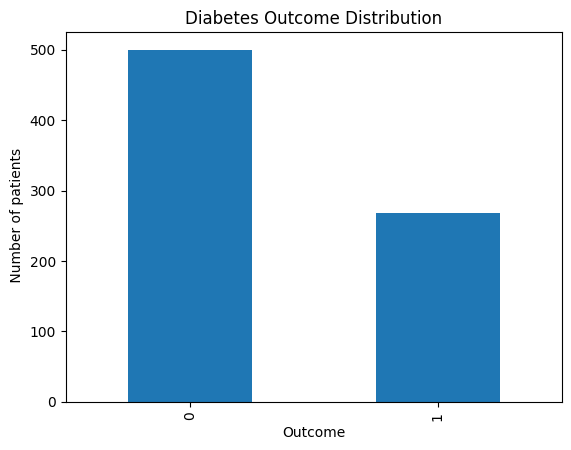

In [10]:
df["Outcome"].value_counts().plot(kind = "bar")
plt.xlabel("Outcome")
plt.ylabel(" Number of patients")
plt.title("Diabetes Outcome Distribution")
plt.show()

# CORRELATION ANALYSIS

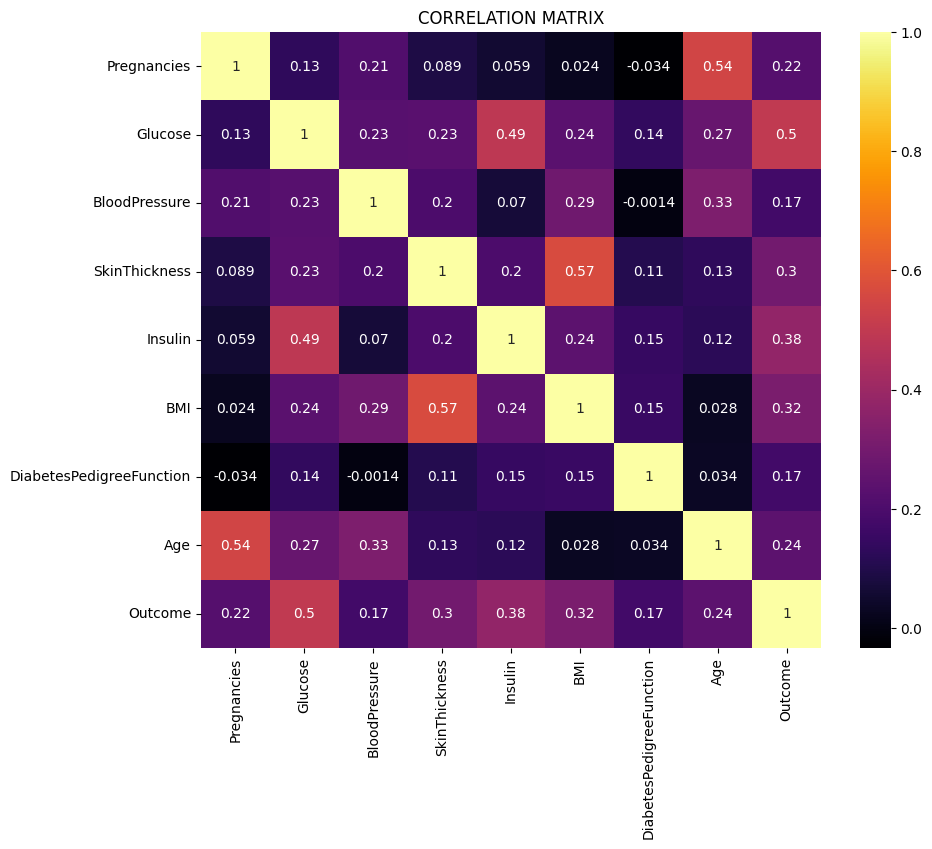

In [11]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(), annot = True, cmap = "inferno")
plt. title ("CORRELATION MATRIX")
plt.show()

# SEPARATING INPUT FEATURES WITH TARGET

In [12]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input features:")
print(X.columns)

print("Target:")
y.name

Input features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str')
Target:


'Outcome'

# SPLITTING DATASET INTO TRAINING AND TESTING DATA

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.05,random_state=0)
print("Training data is ",X_train.shape)
print("Testing  data is ",X_test.shape)

Training data is  (729, 8)
Testing  data is  (39, 8)


# FEATURE SCALING

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# CREATE A MODEL

In [15]:
model = LogisticRegression()

# TRAINING A MODEL

In [16]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# MAKING A PREDICTION

In [17]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0])

# CHECKING ACCURACY

In [18]:
accuracy = accuracy_score(y_test,y_pred)
print(" accuracy (%) is ",accuracy*100)

 accuracy (%) is  89.74358974358975


# CONFUSION MATRIX

In [19]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[25,  3],
       [ 1, 10]])

# DISPLAY CONFUSION MATRIX

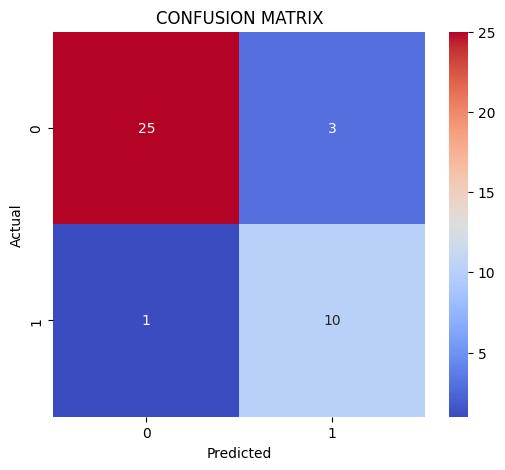

In [20]:
plt.figure( figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CONFUSION MATRIX")
plt.show()

# CLASSIFICATION REPORT

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.89      0.93        28
           1       0.77      0.91      0.83        11

    accuracy                           0.90        39
   macro avg       0.87      0.90      0.88        39
weighted avg       0.91      0.90      0.90        39



# PREDICTION USING MY OWN INPUT FEATURES

In [22]:
pregnancies = float(input(
    "Enter pregnancies: "))
glucose = float(input("Enter glucose: "))
blood_pressure = float(input("Enter blood pressure: "))
skin_thickness = float(input("Enter skin thickness: "))
insulin = float(input("Enter insulin: "))
bmi = float(input("Enter BMI: "))
diabetes_pedigree = float(input("Enter diabetes pedigree function: "))
age = float(input("Enter age: "))

Enter pregnancies:  13
Enter glucose:  12
Enter blood pressure:  14
Enter skin thickness:  6
Enter insulin:  56
Enter BMI:  34
Enter diabetes pedigree function:  13
Enter age:  34


# PUT INPUT FEATURES TOGETHER

In [32]:
new_patient = np.array([[
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
]])

new_patient

array([[13., 12., 14.,  6., 56., 34., 13., 34.]])

# SCALING THE NEW INPUT FEATURES

In [33]:
new_patient_scaled = scaler.transform(new_patient)

C:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# MAKING A PREDICTIONS

In [34]:
prediction = model.predict(new_patient_scaled)
print("prediction is ",prediction[0])

prediction is  1


In [35]:
if prediction[0] == 1:
    print("The model predicts: Diabetes")
else:
    print("The model predicts: No Diabetes")

The model predicts: Diabetes


# PROBABILITY PREDICTIONS

In [36]:
probability = model.predict_proba(new_patient_scaled)

print("Probability of No Diabetes:", probability[0][0])
print("Probability of Diabetes:", probability[0][1])

Probability of No Diabetes: 0.0006744327478968026
Probability of Diabetes: 0.9993255672521032


# HOW TO GET INTERCEPT

In [37]:
constant = model.intercept_
print(constant)

[-0.84522304]


# HOW TO GET WEIGHT OF FEATURES

In [38]:
weights = model.coef_[0]
print(weights)

[ 0.38985134  0.87604192 -0.07533112  0.34619936  0.47658431  0.3941853
  0.29079389  0.16494204]


In [39]:
for feature, weight in zip(X.columns,model.coef_[0]):
    print(feature,":",weight)

Pregnancies : 0.3898513444685191
Glucose : 0.8760419179007998
BloodPressure : -0.07533112257595254
SkinThickness : 0.3461993604231166
Insulin : 0.47658430740643204
BMI : 0.39418530243561556
DiabetesPedigreeFunction : 0.2907938851928441
Age : 0.1649420362387736


# WHOLE FORMULAR OF A MODEL

In [40]:
print("constant :", model.intercept_[0])
for feature, weight in zip(X.columns,model.coef_[0]):
    print(feature,"=",weight)


constant : -0.845223044308911
Pregnancies = 0.3898513444685191
Glucose = 0.8760419179007998
BloodPressure = -0.07533112257595254
SkinThickness = 0.3461993604231166
Insulin = 0.47658430740643204
BMI = 0.39418530243561556
DiabetesPedigreeFunction = 0.2907938851928441
Age = 0.1649420362387736


SyntaxError: invalid syntax (2318340849.py, line 1)